# 04 — Aprendizaje Activo
### Freesound Audio Tagging 2019

El aprendizaje activo responde a la pregunta: **¿cuál es el próximo audio que más
me conviene etiquetar?**

Estrategia: **Uncertainty Sampling**

## 1. Carga de datos

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

FEATURES_DIR = Path("features")

X_pca_curated    = np.load(FEATURES_DIR / "X_pca_full.npy")
y_curated        = np.load(FEATURES_DIR / "y_curated.npy")
X_pca_noisy      = np.load(FEATURES_DIR / "X_pca_noisy.npy")
y_noisy_raw      = np.load(FEATURES_DIR / "y_noisy_raw.npy")   # como oráculo
y_noisy_prop     = np.load(FEATURES_DIR / "y_noisy_propagated.npy")
X_test           = np.load(FEATURES_DIR / "X_test.npy")
y_test           = np.load(FEATURES_DIR / "y_test.npy")

with open(FEATURES_DIR / "label_encoder.pkl", "rb") as f:
    le = pickle.load(f)

# Filtrar noisy con etiquetas conocidas (y_noisy_raw != -1) para simular oráculo
oracle_mask = y_noisy_raw != -1
X_pool      = X_pca_noisy[oracle_mask]
y_pool      = y_noisy_raw[oracle_mask]  # oráculo: etiqueta ruidosa disponible
y_pool_prop = y_noisy_prop[oracle_mask]

print(f"Pool de datos no etiquetados (noisy con label conocida): {X_pool.shape}")
print(f"Datos etiquetados iniciales (curated): {X_pca_curated.shape}")
print(f"Test set: {X_test.shape}")

Pool de datos no etiquetados (noisy con label conocida): (19326, 56)
Datos etiquetados iniciales (curated): (4970, 56)
Test set: (994, 56)


## 2. Función de Uncertainty Sampling

Tres métricas de incertidumbre:

| Estrategia | Fórmula | Que selecciona |
|---|---|---|
| Least Confident | `1 - max(P)` | El más difícil de clasificar |
| Margin Sampling | `P1 - P2` (top-2) | Menor margen entre las 2 mejores clases |
| Entropy | `-Σ P*log(P)` | Mayor incertidumbre total |

In [2]:
def uncertainty_least_confident(probas):
    """1 - P(clase más probable). Mayor valor = más incierto."""
    return 1.0 - probas.max(axis=1)

def uncertainty_margin(probas):
    """Diferencia entre top-2 probabilidades. Menor margen = más incierto."""
    sorted_p = np.sort(probas, axis=1)[:, ::-1]
    return 1.0 - (sorted_p[:, 0] - sorted_p[:, 1])

def uncertainty_entropy(probas):
    """Entropía de Shannon. Mayor entropía = más incierto."""
    eps = 1e-10  # evitar log(0)
    return -np.sum(probas * np.log(probas + eps), axis=1)

def select_by_uncertainty(model, X_pool, n_select, strategy='entropy'):
    """
    Selecciona los n_select ejemplos más inciertos del pool.
    Retorna los índices.
    """
    probas = model.predict_proba(X_pool)
    
    if strategy == 'least_confident':
        scores = uncertainty_least_confident(probas)
    elif strategy == 'margin':
        scores = uncertainty_margin(probas)
    else:  # entropy
        scores = uncertainty_entropy(probas)
    
    # Los de MAYOR score son los más inciertos
    return np.argsort(scores)[::-1][:n_select]

print("Funciones de incertidumbre definidas.")

Funciones de incertidumbre definidas.


## 3. Simulación de aprendizaje activo

Simulamos el proceso iterativo:
1. Empezamos con un subconjunto pequeño de curated
2. En cada iteración, pedimos al "oráculo" (noisy labels) que etiquete N ejemplos
3. Comparamos: selección por incertidumbre vs selección aleatoria

In [3]:
# ── Parámetros de la simulación ──────────────────────────────────────────────
N_INITIAL     = 200    # ejemplos iniciales de curated
N_QUERY       = 100    # ejemplos a pedir al oráculo en cada iteración
N_ITERATIONS  = 20     # número de rondas de aprendizaje activo
STRATEGY      = 'entropy'  # 'entropy', 'margin', 'least_confident'
N_POOL_SAMPLE = 5000   # muestra del pool para evaluar incertidumbre (eficiencia)
# ─────────────────────────────────────────────────────────────────────────────

print(f"Configuración:")
print(f"  Datos iniciales    : {N_INITIAL}")
print(f"  Queries por ronda  : {N_QUERY}")
print(f"  Iteraciones        : {N_ITERATIONS}")
print(f"  Estrategia         : {STRATEGY}")
print(f"  Total potencial    : {N_INITIAL + N_QUERY * N_ITERATIONS} ejemplos")

Configuración:
  Datos iniciales    : 200
  Queries por ronda  : 100
  Iteraciones        : 20
  Estrategia         : entropy
  Total potencial    : 2200 ejemplos


In [4]:
# ── Inicialización ───────────────────────────────────────────────────────────
# Tomar N_INITIAL primeros de curated como conjunto inicial
np.random.seed(42)
init_idx = np.random.choice(len(X_pca_curated), N_INITIAL, replace=False)

X_labeled   = X_pca_curated[init_idx].copy()
y_labeled   = y_curated[init_idx].copy()

# Pool de datos no etiquetados (muestra manejable)
pool_size = min(N_POOL_SAMPLE, len(X_pool))
pool_idx  = np.random.choice(len(X_pool), pool_size, replace=False)
X_pool_sample = X_pool[pool_idx].copy()
y_pool_sample = y_pool[pool_idx].copy()

# Máscaras para saber qué ya etiquetamos
remaining_mask_active = np.ones(pool_size, dtype=bool)   # uncertain
remaining_mask_random = np.ones(pool_size, dtype=bool)   # random

X_labeled_random = X_labeled.copy()
y_labeled_random = y_labeled.copy()

print(f"Pool de muestra: {X_pool_sample.shape}")
print(f"Conjunto inicial etiquetado: {X_labeled.shape}")

Pool de muestra: (5000, 56)
Conjunto inicial etiquetado: (200, 56)


In [5]:
# ── Loop principal ───────────────────────────────────────────────────────────
acc_active = []
acc_random = []
n_labeled  = [N_INITIAL]

print(f"{'Iter':>4} | {'N etiquetados':>13} | {'Activo (entropy)':>17} | {'Aleatorio':>10}")
print("-" * 55)

for it in range(N_ITERATIONS):
    
    # ── Activo: entrenar con los etiquetados actuales ─────────────────────
    clf_active = LogisticRegression(max_iter=500, random_state=42,
                                    solver='saga', n_jobs=-1)
    clf_active.fit(X_labeled, y_labeled)
    acc = clf_active.score(X_test, y_test)
    acc_active.append(acc)
    
    # ── Random: entrenar con los etiquetados actuales ─────────────────────
    clf_random = LogisticRegression(max_iter=500, random_state=42,
                                    solver='saga', n_jobs=-1)
    clf_random.fit(X_labeled_random, y_labeled_random)
    acc_r = clf_random.score(X_test, y_test)
    acc_random.append(acc_r)
    
    print(f"{it+1:>4} | {len(X_labeled):>13} | {acc:>17.4f} | {acc_r:>10.4f}")
    
    # ── Seleccionar próximos ejemplos (activo) ────────────────────────────
    if remaining_mask_active.sum() >= N_QUERY:
        avail_idxs = np.where(remaining_mask_active)[0]
        X_avail    = X_pool_sample[avail_idxs]
        
        # Calcular incertidumbre sobre el subconjunto disponible
        query_local = select_by_uncertainty(
            clf_active, X_avail, N_QUERY, strategy=STRATEGY
        )
        query_global = avail_idxs[query_local]
        
        # Agregar al conjunto etiquetado
        X_labeled = np.vstack([X_labeled, X_pool_sample[query_global]])
        y_labeled = np.concatenate([y_labeled, y_pool_sample[query_global]])
        remaining_mask_active[query_global] = False
    
    # ── Seleccionar próximos ejemplos (random) ────────────────────────────
    if remaining_mask_random.sum() >= N_QUERY:
        avail_idxs_r = np.where(remaining_mask_random)[0]
        rnd_local    = np.random.choice(len(avail_idxs_r), N_QUERY, replace=False)
        rnd_global   = avail_idxs_r[rnd_local]
        
        X_labeled_random = np.vstack([X_labeled_random, X_pool_sample[rnd_global]])
        y_labeled_random = np.concatenate([y_labeled_random, y_pool_sample[rnd_global]])
        remaining_mask_random[rnd_global] = False
    
    n_labeled.append(len(X_labeled))

print("\nSimulación completa.")

Iter | N etiquetados |  Activo (entropy) |  Aleatorio
-------------------------------------------------------
   1 |           200 |            0.1801 |     0.1801
   2 |           300 |            0.1600 |     0.1690
   3 |           400 |            0.1509 |     0.1509
   4 |           500 |            0.1459 |     0.1408
   5 |           600 |            0.1328 |     0.1197
   6 |           700 |            0.1308 |     0.1288
   7 |           800 |            0.1288 |     0.1187
   8 |           900 |            0.1237 |     0.1117
   9 |          1000 |            0.1227 |     0.1016
  10 |          1100 |            0.1147 |     0.1016
  11 |          1200 |            0.1107 |     0.1016
  12 |          1300 |            0.1036 |     0.1056
  13 |          1400 |            0.1097 |     0.0976
  14 |          1500 |            0.1076 |     0.0926
  15 |          1600 |            0.1087 |     0.0996
  16 |          1700 |            0.1107 |     0.1016
  17 |          1800 |    

## 4. Curvas de aprendizaje activo

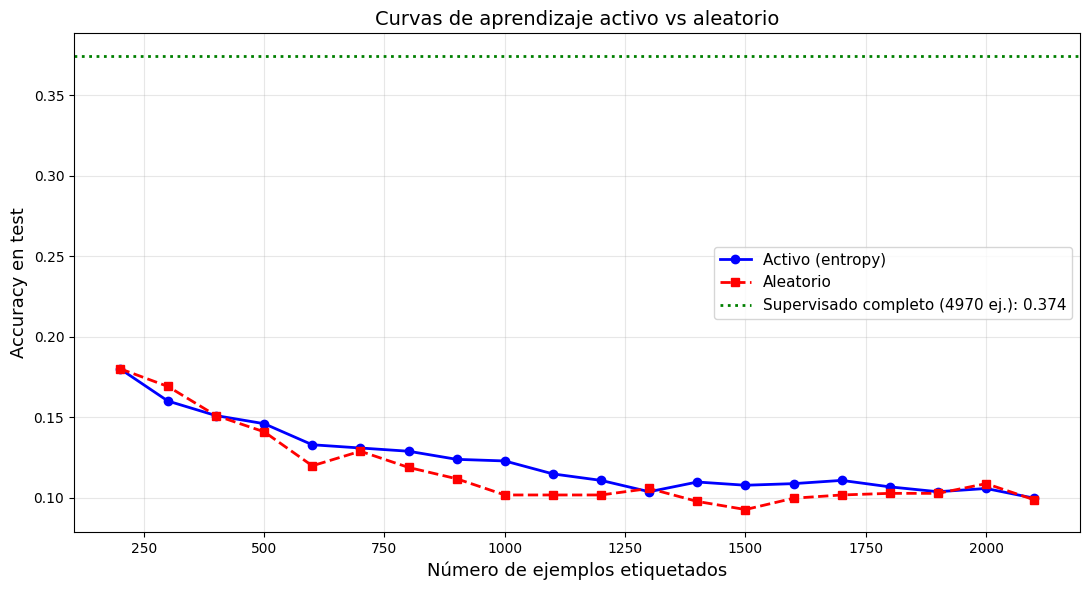

Ventaja promedio del activo sobre aleatorio: +0.61 pp
Ventaja máxima                            : +2.11 pp


In [6]:
plt.figure(figsize=(11, 6))

x_axis = n_labeled[:-1]  # número de ejemplos etiquetados en cada iteración

plt.plot(x_axis, acc_active, 'b-o', markersize=6, linewidth=2,
         label=f'Activo ({STRATEGY})')
plt.plot(x_axis, acc_random, 'r--s', markersize=6, linewidth=2,
         label='Aleatorio')

# Línea de referencia: supervisado con todo curated
with open(FEATURES_DIR / "log_reg_base.pkl", "rb") as f:
    log_reg_base = pickle.load(f)
acc_full = log_reg_base.score(X_test, y_test)
plt.axhline(y=acc_full, color='green', linestyle=':', linewidth=2,
            label=f'Supervisado completo ({len(X_pca_curated)} ej.): {acc_full:.3f}')

plt.xlabel("Número de ejemplos etiquetados", fontsize=13)
plt.ylabel("Accuracy en test", fontsize=13)
plt.title("Curvas de aprendizaje activo vs aleatorio", fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Ventaja del activo sobre el aleatorio
ventaja = np.array(acc_active) - np.array(acc_random)
print(f"Ventaja promedio del activo sobre aleatorio: {ventaja.mean()*100:+.2f} pp")
print(f"Ventaja máxima                            : {ventaja.max()*100:+.2f} pp")

## 5. Comparación de las tres estrategias

In [7]:
# Función para correr una simulación completa con una estrategia dada
def run_active_learning(X_pca_curated, y_curated, X_pool_sample, y_pool_sample,
                        X_test, y_test, strategy, n_initial=N_INITIAL,
                        n_query=N_QUERY, n_iter=N_ITERATIONS, seed=42):
    np.random.seed(seed)
    init_idx = np.random.choice(len(X_pca_curated), n_initial, replace=False)
    X_lab = X_pca_curated[init_idx].copy()
    y_lab = y_curated[init_idx].copy()
    remaining = np.ones(len(X_pool_sample), dtype=bool)
    accuracies = []
    n_labeled  = [n_initial]
    
    for _ in range(n_iter):
        clf = LogisticRegression(max_iter=500, random_state=seed, solver='saga', n_jobs=-1)
        clf.fit(X_lab, y_lab)
        accuracies.append(clf.score(X_test, y_test))
        
        avail = np.where(remaining)[0]
        if len(avail) < n_query:
            break
        
        if strategy == 'random':
            sel_local = np.random.choice(len(avail), n_query, replace=False)
        else:
            sel_local = select_by_uncertainty(clf, X_pool_sample[avail], n_query, strategy)
        
        sel_global = avail[sel_local]
        X_lab = np.vstack([X_lab, X_pool_sample[sel_global]])
        y_lab = np.concatenate([y_lab, y_pool_sample[sel_global]])
        remaining[sel_global] = False
        n_labeled.append(len(X_lab))
    
    return n_labeled[:-1], accuracies

print("Ejecutando las 4 estrategias... (puede tardar varios minutos)")

strategies = ['entropy', 'margin', 'least_confident', 'random']
results    = {}

for strat in strategies:
    print(f"  {strat}...")
    ns, accs = run_active_learning(
        X_pca_curated, y_curated, X_pool_sample, y_pool_sample,
        X_test, y_test, strategy=strat
    )
    results[strat] = (ns, accs)

print("\nListo.")

Ejecutando las 4 estrategias... (puede tardar varios minutos)
  entropy...
  margin...
  least_confident...
  random...

Listo.


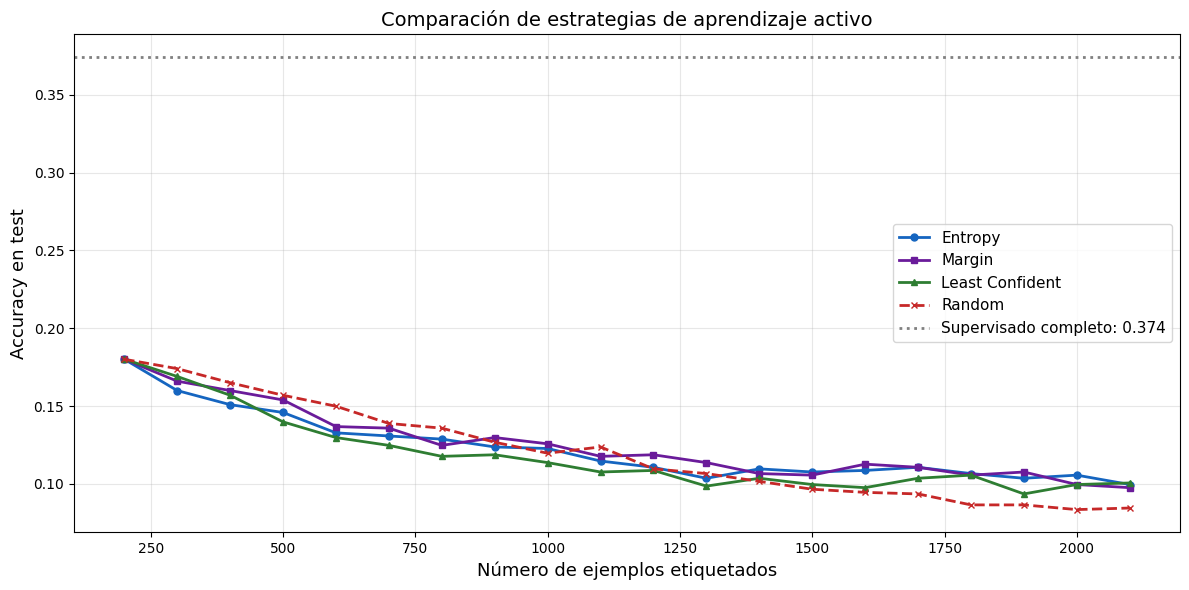

In [8]:
plt.figure(figsize=(12, 6))

colores = {'entropy': '#1565C0', 'margin': '#6A1B9A',
           'least_confident': '#2E7D32', 'random': '#C62828'}
estilos = {'entropy': '-o', 'margin': '-s', 'least_confident': '-^', 'random': '--x'}

for strat, (ns, accs) in results.items():
    plt.plot(ns, accs, estilos[strat], markersize=5, linewidth=2,
             color=colores[strat], label=strat.replace('_', ' ').title())

plt.axhline(y=acc_full, color='gray', linestyle=':', linewidth=2,
            label=f'Supervisado completo: {acc_full:.3f}')

plt.xlabel("Número de ejemplos etiquetados", fontsize=13)
plt.ylabel("Accuracy en test", fontsize=13)
plt.title("Comparación de estrategias de aprendizaje activo", fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Análisis de los ejemplos más inciertos

In [9]:
# Entrenar con todos los curated
clf_final = LogisticRegression(max_iter=2000, random_state=42, solver='saga', n_jobs=-1)
clf_final.fit(X_pca_curated, y_curated)

# Predecir sobre el pool
probas_pool = clf_final.predict_proba(X_pool_sample)
entropy_scores = uncertainty_entropy(probas_pool)

# Top 30 más inciertos
top_uncertain = np.argsort(entropy_scores)[::-1][:30]
top_certain   = np.argsort(entropy_scores)[:30]

# Clases reales de los más inciertos vs más ciertos
print("Top 10 MÁS INCIERTOS (mayor entropía):")
for i in top_uncertain[:10]:
    clase_real = le.classes_[y_pool_sample[i]]
    pred_class = le.classes_[probas_pool[i].argmax()]
    conf = probas_pool[i].max()
    print(f"  Entropía={entropy_scores[i]:.3f} | Real: {clase_real:<20s} | Pred: {pred_class:<20s} | Conf: {conf:.2f}")

print("\nTop 10 MÁS CIERTOS (menor entropía):")
for i in top_certain[:10]:
    clase_real = le.classes_[y_pool_sample[i]]
    pred_class = le.classes_[probas_pool[i].argmax()]
    conf = probas_pool[i].max()
    print(f"  Entropía={entropy_scores[i]:.3f} | Real: {clase_real:<20s} | Pred: {pred_class:<20s} | Conf: {conf:.2f}")

Top 10 MÁS INCIERTOS (mayor entropía):
  Entropía=3.620 | Real: Computer_keyboard    | Pred: Squeak               | Conf: 0.08
  Entropía=3.510 | Real: Keys_jangling        | Pred: Bass_drum            | Conf: 0.11
  Entropía=3.482 | Real: Computer_keyboard    | Pred: Chirp_and_tweet      | Conf: 0.12
  Entropía=3.477 | Real: Skateboard           | Pred: Printer              | Conf: 0.15
  Entropía=3.414 | Real: Hiss                 | Pred: Run                  | Conf: 0.09
  Entropía=3.406 | Real: Gasp                 | Pred: Writing              | Conf: 0.09
  Entropía=3.396 | Real: Skateboard           | Pred: Cheering             | Conf: 0.12
  Entropía=3.392 | Real: Drawer_open_or_close | Pred: Buzz                 | Conf: 0.13
  Entropía=3.386 | Real: Applause             | Pred: Chirp_and_tweet      | Conf: 0.14
  Entropía=3.383 | Real: Cricket              | Pred: Cricket              | Conf: 0.11

Top 10 MÁS CIERTOS (menor entropía):
  Entropía=0.000 | Real: Raindrop          

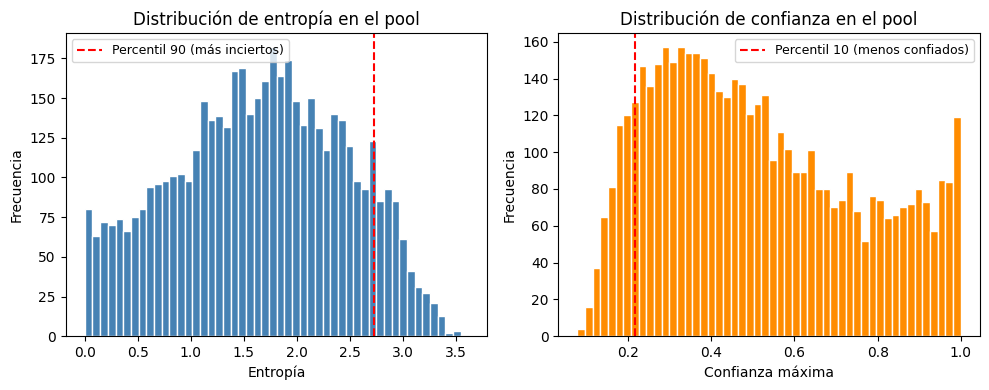

In [10]:
# Distribución de entropía
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(entropy_scores, bins=50, color='steelblue', edgecolor='white')
plt.axvline(x=np.percentile(entropy_scores, 90), color='red', linestyle='--',
            label='Percentil 90 (más inciertos)')
plt.xlabel("Entropía")
plt.ylabel("Frecuencia")
plt.title("Distribución de entropía en el pool")
plt.legend(fontsize=9)

plt.subplot(1, 2, 2)
conf_scores = probas_pool.max(axis=1)
plt.hist(conf_scores, bins=50, color='darkorange', edgecolor='white')
plt.axvline(x=np.percentile(conf_scores, 10), color='red', linestyle='--',
            label='Percentil 10 (menos confiados)')
plt.xlabel("Confianza máxima")
plt.ylabel("Frecuencia")
plt.title("Distribución de confianza en el pool")
plt.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 7. Resumen final del trabajo completo

In [ ]:
with open(FEATURES_DIR / "log_reg_semi.pkl", "rb") as f:
    log_reg_semi = pickle.load(f)

acc_semi = log_reg_semi.score(X_test, y_test)
acc_activo_final = results['entropy'][1][-1]
n_activo_final   = results['entropy'][0][-1]

print("=" * 60)
print("RESUMEN FINAL — Freesound Audio Tagging 2019")
print("=" * 60)
print(f"\nDataset:")
print(f"  train_curated (etiquetados)   : {len(X_pca_curated):>7} audios")
print(f"  train_noisy (sin etiq. limpia): {len(X_pca_noisy):>7} audios")
print(f"  Clases                        : {len(le.classes_):>7}")
print(f"\nResultados:")
print(f"  Supervisado (curated only)         : {acc_full:.4f}")
print(f"  Semisupervisado (KMeans propagación): {acc_semi:.4f}  ({(acc_semi-acc_full)*100:+.2f} pp)")
print(f"  Activo (entropy, {n_activo_final} ej.)        : {acc_activo_final:.4f}  ({(acc_activo_final-acc_full)*100:+.2f} pp)")
print(f"\nConclusión:")
"""
if acc_semi > acc_full:
    print(f"  El aprendizaje semisupervisado mejora el baseline.")
else:
    print(f"  El aprendizaje semisupervisado no supera el baseline en esta configuración.")
    print(f"  Posibles mejoras: ajustar k, usar mejores features, o aumentar la confianza del mapeo.")
print("=" * 60)

"""

RESUMEN FINAL — Freesound Audio Tagging 2019

Dataset:
  train_curated (etiquetados)   :    4970 audios
  train_noisy (sin etiq. limpia):   19815 audios
  Clases                        :      78

Resultados:
  Supervisado (curated only)         : 0.3742
  Semisupervisado (KMeans propagación): 0.3451  (-2.92 pp)
  Activo (entropy, 2100 ej.)        : 0.0996  (-27.46 pp)

Conclusión:
  El aprendizaje semisupervisado no supera el baseline en esta configuración.
  Posibles mejoras: ajustar k, usar mejores features, o aumentar la confianza del mapeo.
